In [124]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report as cr
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import joblib as jb 
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

Loading the dataset ⏳

In [125]:
dataset = pd.read_csv('Mall_Customers.csv')
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [126]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [127]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Preprocessing the Data 🛠️

In [128]:
print(dataset.duplicated(), '\n')
print('The sum of duplicated values is: ', dataset.duplicated().sum())

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool 

The sum of duplicated values is:  0


In [129]:
#check for null values 
print(dataset.isnull(), '\n')
print('The sum of null values is: ', dataset.isnull().sum())

     CustomerID  Genre    Age  Annual Income (k$)  Spending Score (1-100)
0         False  False  False               False                   False
1         False  False  False               False                   False
2         False  False  False               False                   False
3         False  False  False               False                   False
4         False  False  False               False                   False
..          ...    ...    ...                 ...                     ...
195       False  False  False               False                   False
196       False  False  False               False                   False
197       False  False  False               False                   False
198       False  False  False               False                   False
199       False  False  False               False                   False

[200 rows x 5 columns] 

The sum of null values is:  CustomerID                0
Genre                     0
Ag

In [130]:
#label encoding
le = LabelEncoder()
dataset['Genre'] = le.fit_transform(dataset['Genre'])
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [131]:
#drop the useless feature
if 'CustomerID' in dataset.columns: 
    dataset = dataset.drop('CustomerID', axis = 1)

dataset

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [132]:
#scaling the data
scaler = StandardScaler()
scaled_dataset = scaler.fit_transform(dataset)

original_data = dataset.copy()
original_data

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [133]:
#applying Principle Component Analysis
pca = PCA(n_components = 2)
pca_dataset = pca.fit_transform(scaled_dataset)
dataset = pd.DataFrame(data = pca_dataset, columns = ['PC1', 'PC2'])


Exploratory Data Analysis 📊

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_45268/2120919673.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[i])


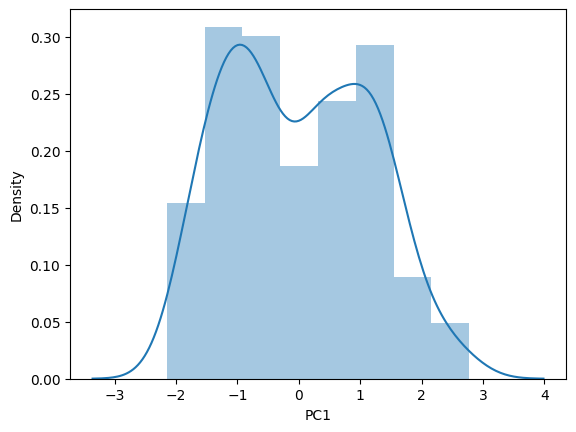

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_45268/2120919673.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[i])


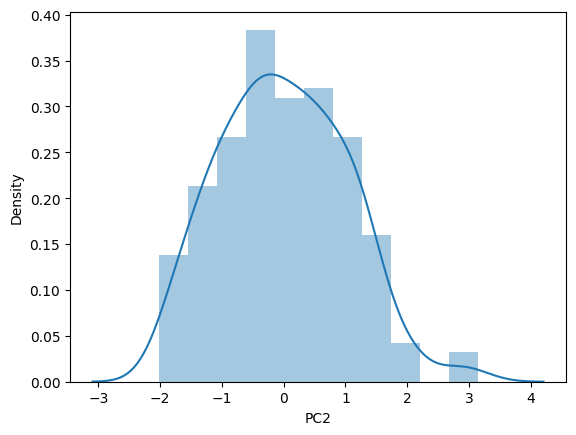

In [134]:
#distrubution plot
features = dataset.columns
for i in features:
    sns.distplot(dataset[i])
    plt.show()

Text(0, 0.5, 'Values')

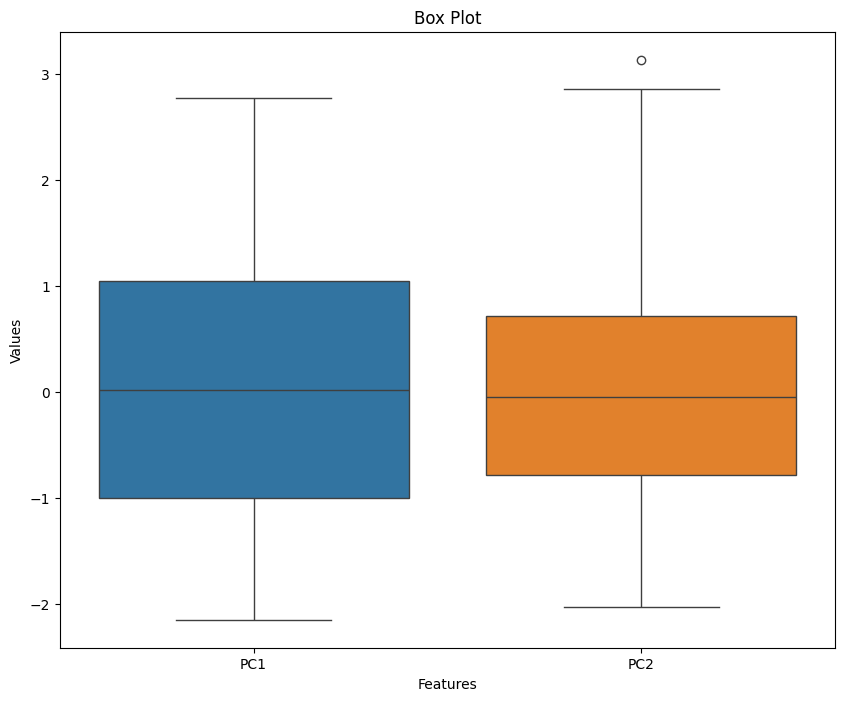

In [135]:
#box plots
plt.figure(figsize=(10, 8))
sns.boxplot(data = dataset)
plt.title('Box Plot')
plt.xlabel('Features')
plt.ylabel('Values')

Text(0, 0.5, 'Values')

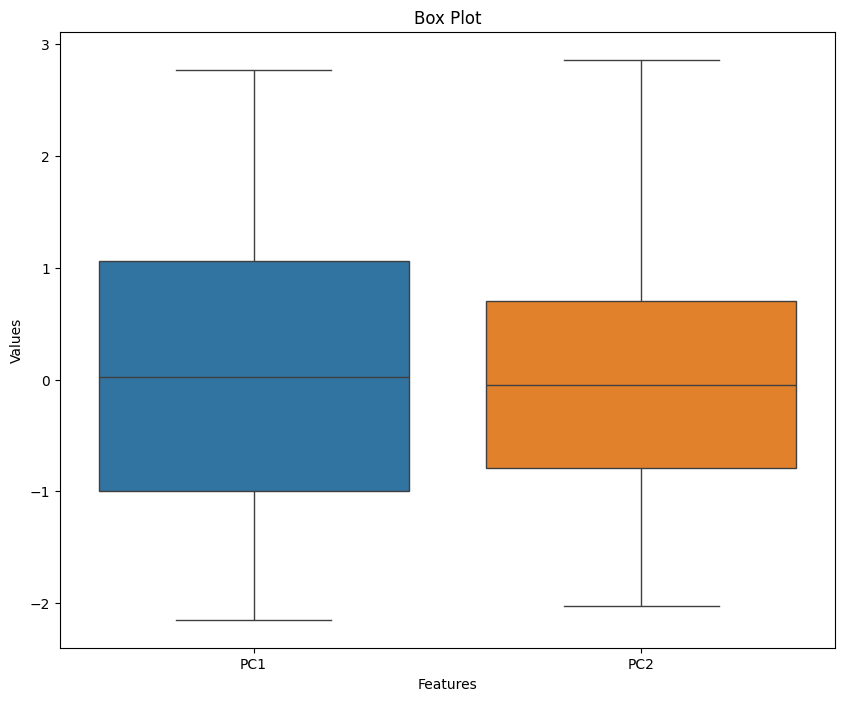

In [136]:
#remove outliers
Q1 = dataset.quantile(0.25)
Q3 = dataset.quantile(0.75)
IQR = Q3 - Q1
dataset = dataset[~((dataset < (Q1 - 1.5 * IQR)) | (dataset > (Q3 + 1.5 * IQR))).any(axis=1)]

Q1_ = original_data.quantile(0.25)
Q3_ = original_data.quantile(0.75)
IQR_ = Q3_ - Q1_
original_data = original_data[~((original_data < (Q1_ - 1.5 * IQR_)) | (original_data > (Q3_ + 1.5 * IQR_))).any(axis=1)]

#box plots after removing outliers
plt.figure(figsize=(10, 8))
sns.boxplot(data = dataset)
plt.title('Box Plot')
plt.xlabel('Features')
plt.ylabel('Values')

In [137]:
#correlation matrix
correlation_matrix = dataset.corr()
correlation_matrix

,PC1,PC2
PC1,1.000000,0.014496
PC2,0.014496,1.000000


Training the Model 💪

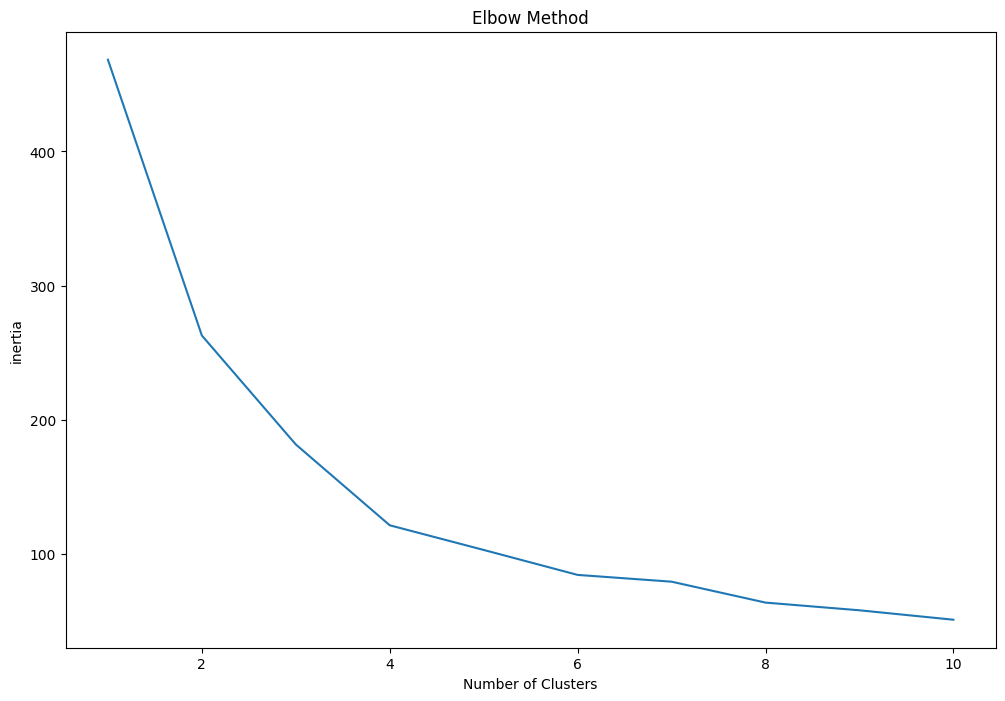

In [138]:
#elbow method 
inertia = []
for i in range(1, 11):
    model = KMeans(n_clusters = i, random_state = 42)
    model.fit(dataset)
    inertia.append(model.inertia_)
plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('inertia')
plt.show()

In [139]:
model = KMeans(n_clusters = 4, random_state = 42)
model.fit(dataset)
dataset['Cluster'] = model.labels_
dataset

,PC1,PC2,Cluster
0,-0.406383,-0.520714,2
1,-1.427673,-0.367310,2
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,2
4,-0.313108,-1.810483,3
...,...,...,...
194,1.092888,0.982841,0
195,-1.179572,1.324568,1
196,0.672751,1.221061,0
197,-0.723719,2.765010,1


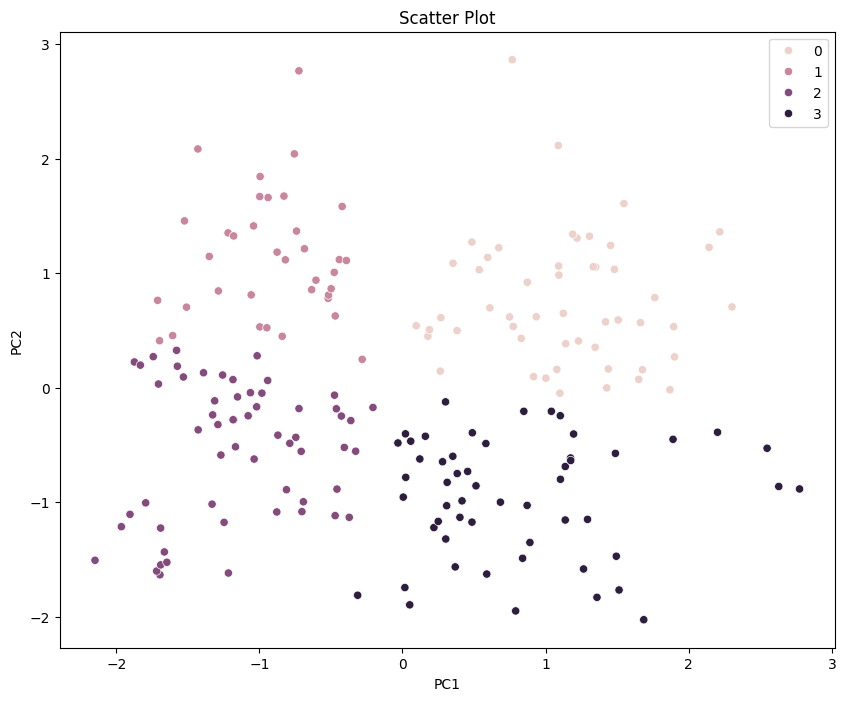

In [140]:
#scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x = 'PC1', y = 'PC2', hue = 'Cluster', data = dataset)
plt.title('Scatter Plot')
plt.legend()

In [141]:
param_grid = {
    'n_clusters': range(2, 11),
    'init': ['k-means++', 'random'],
    'max_iter': [100, 300, 500]
}

grid_search = GridSearchCV(KMeans(), param_grid, cv = 5)
grid_search.fit(dataset)

print('Best Parameters: ', grid_search.best_params_)
print('Best Score: ', grid_search.best_score_)
print('Best Model: ', grid_search.best_estimator_)

Best Parameters:  {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 10}
Best Score:  -22.05964019436439
Best Model:  KMeans(max_iter=100, n_clusters=10)


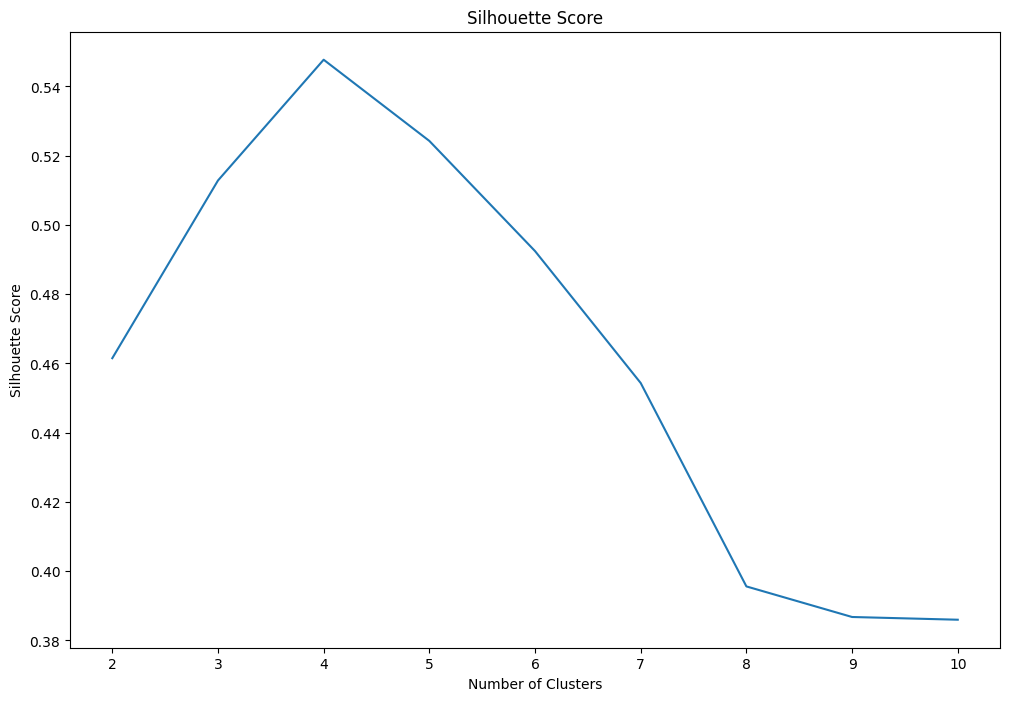

In [142]:
#now finally clustering with silhouette score
silhouette_scores = []
for i in range(2, 11):
    model = KMeans(n_clusters = i, random_state = 42)
    model.fit(dataset)
    silhouette_scores.append(silhouette_score(dataset, model.labels_))

plt.figure(figsize=(12, 8))
plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [143]:
model = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 100, random_state = 42)
model.fit(dataset)
dataset['Cluster'] = model.labels_
dataset

,PC1,PC2,Cluster
0,-0.406383,-0.520714,2
1,-1.427673,-0.367310,2
2,0.050761,-1.894068,1
3,-1.694513,-1.631908,2
4,-0.313108,-1.810483,1
...,...,...,...
194,1.092888,0.982841,0
195,-1.179572,1.324568,3
196,0.672751,1.221061,0
197,-0.723719,2.765010,3


In [144]:
original_data['Cluster'] = dataset['Cluster']
original_data

/var/folders/_g/3jm_h3c15k34rwm0w2rtr0wh0000gn/T/ipykernel_45268/3615914642.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  original_data['Cluster'] = dataset['Cluster']


,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,1
3,0,23,16,77,2
4,0,31,17,40,1
...,...,...,...,...,...
193,0,38,113,91,3
194,0,47,120,16,0
195,0,35,120,79,3
196,0,45,126,28,0


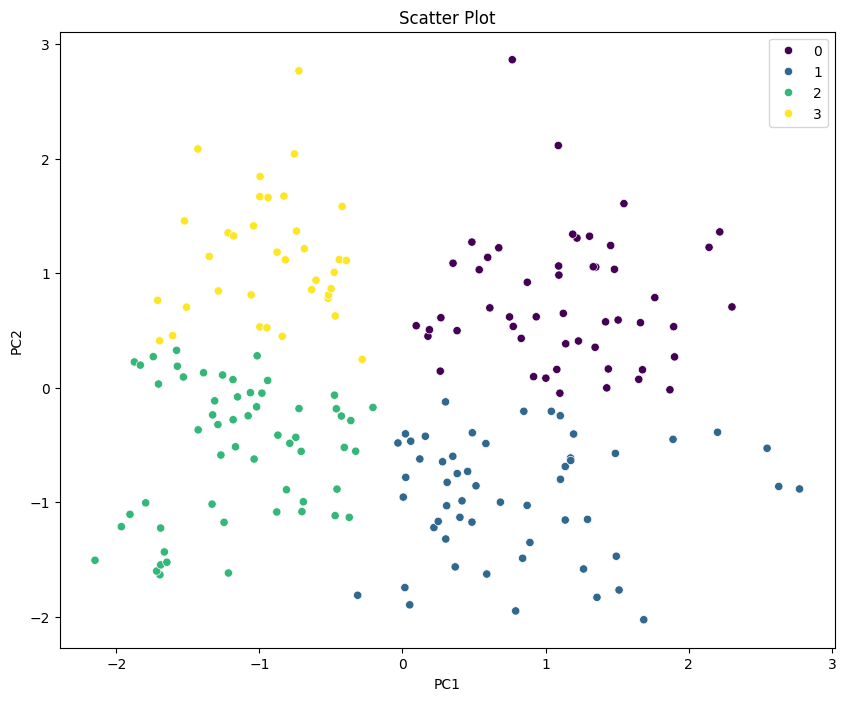

In [165]:
#again visualizing 
plt.figure(figsize=(10, 8))
sns.scatterplot(x = 'PC1', y = 'PC2', hue = 'Cluster', data = dataset, palette = 'viridis')
plt.title('Scatter Plot')
plt.legend()

Classification Models 💪

1️⃣ Decision Tree 

In [192]:
X = original_data.drop('Cluster', axis = 1)
y = original_data['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [193]:
param_grid = {
    'max_depth': [3, 5, 10],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random']
}
model1 = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
model1.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10],
                         'splitter': ['best', 'random']})

In [194]:
print('Best Parameters: ', model1.best_params_)

Best Parameters:  {'criterion': 'entropy', 'max_depth': 10, 'splitter': 'random'}


In [196]:
model1 = DecisionTreeClassifier(max_depth = 10, criterion = 'entropy', splitter = 'random')
model1.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, splitter='random')

In [197]:
Actual_valus = y_test.values
Predicted_values = model1.predict(X_test)

print('Accuracy: ', accuracy_score(Actual_valus, Predicted_values) * 100)

Accuracy:  92.5


In [198]:
#classification report
print(cr(Actual_valus, Predicted_values))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      1.00      1.00        11
           2       0.85      0.92      0.88        12
           3       1.00      0.78      0.88         9

    accuracy                           0.93        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.93      0.93      0.92        40



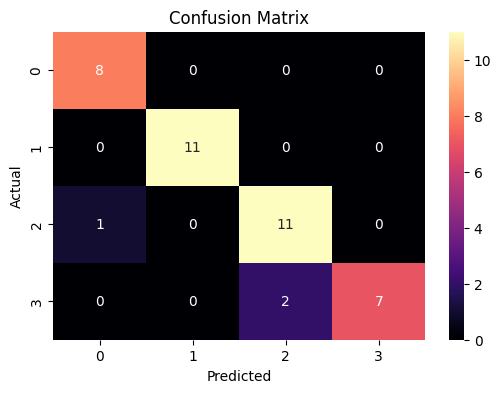

In [199]:
#confusion matrix
confusion_matrix = cm(Actual_valus, Predicted_values)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix, annot=True, cmap='magma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

2️⃣ Logistic Regression

In [181]:
X2 = original_data.drop('Cluster', axis = 1)
y2 = original_data['Cluster']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 42)

In [182]:
model2 = LogisticRegression(C = 0.1)
model2.fit(X_train2, y_train2)

/Users/Sohaib's Macbook Air/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.1)

In [183]:
Actual_valus2 = y_test2.values
Predicted_values2 = model2.predict(X_test2)

print('Accuracy: ', accuracy_score(Actual_valus2, Predicted_values2) * 100)

Accuracy:  87.5


In [184]:
#classification report
print(cr(Actual_valus2, Predicted_values2))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.83      0.91      0.87        11
           2       0.86      1.00      0.92        12
           3       1.00      0.78      0.88         9

    accuracy                           0.88        40
   macro avg       0.89      0.86      0.87        40
weighted avg       0.88      0.88      0.87        40



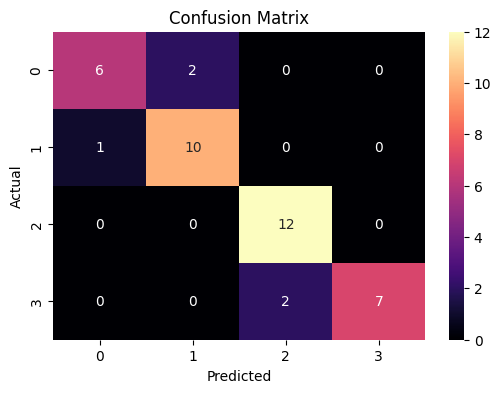

In [185]:
#confusion matrix
confusion_matrix2 = cm(Actual_valus2, Predicted_values2)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix2, annot=True, cmap='magma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

 3️⃣ Random Forest

In [186]:
X3 = original_data.drop('Cluster', axis = 1)
y3 = original_data['Cluster']
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size = 0.2, random_state = 42)

In [187]:
model3 = RandomForestClassifier()
model3.fit(X_train3, y_train3)

RandomForestClassifier()

In [188]:
Actual_valus3 = y_test3.values
Predicted_values3 = model3.predict(X_test3)

print('Accuracy: ', accuracy_score(Actual_valus3, Predicted_values3) * 100)

Accuracy:  97.5


In [189]:
#classification report
print(cr(Actual_valus3, Predicted_values3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        11
           2       0.92      1.00      0.96        12
           3       1.00      0.89      0.94         9

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.98        40
weighted avg       0.98      0.97      0.97        40



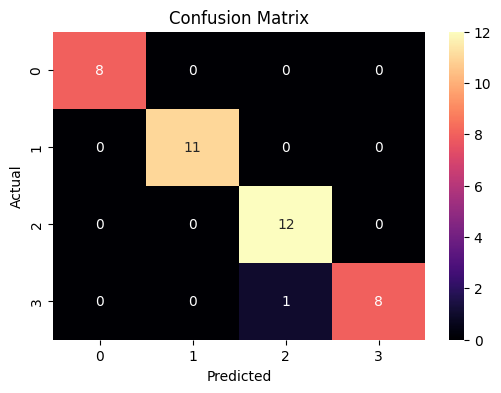

In [190]:
#confusion matrix
confusion_matrix3 = cm(Actual_valus3, Predicted_values3)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix3, annot=True, cmap='magma')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [191]:
joblib.dump(model, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca_model.pkl')
joblib.dump(model1, 'decision_tree.pkl')
joblib.dump(model2, 'logistic_regression.pkl')
joblib.dump(model3, 'random_forest.pkl')

['random_forest.pkl']